# Prédiction du niveau d'éducation parentale

Trois analyses de régression logistique sur student-por :
1. **Medu binaire** : mère faible (0–2) vs élevée (3–4) — avec Fedu comme feature
2. **Fedu binaire** : père faible (0–2) vs élevé (3–4) — avec Medu comme feature
3. **Medu 4 niveaux** : primaire/aucun (0–1), collège (2), lycée (3), supérieur (4)


## 1. Imports et chargement

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

student_mat = pd.read_csv('../donnees/student-mat.csv')
student_por = pd.read_csv('../donnees/student-por.csv')
student_mat = student_por  # analyse sur le dataset portugais
print(f'Dataset : {student_mat.shape[0]} élèves, {student_mat.shape[1]} variables')


Dataset : 649 élèves, 33 variables


## 2. Corrélations avec Medu

Avant de construire le modèle, on visualise les corrélations entre Medu et les variables
qu'on suppose liées à l'éducation maternelle. Les variables booléennes sont encodées en 0/1.


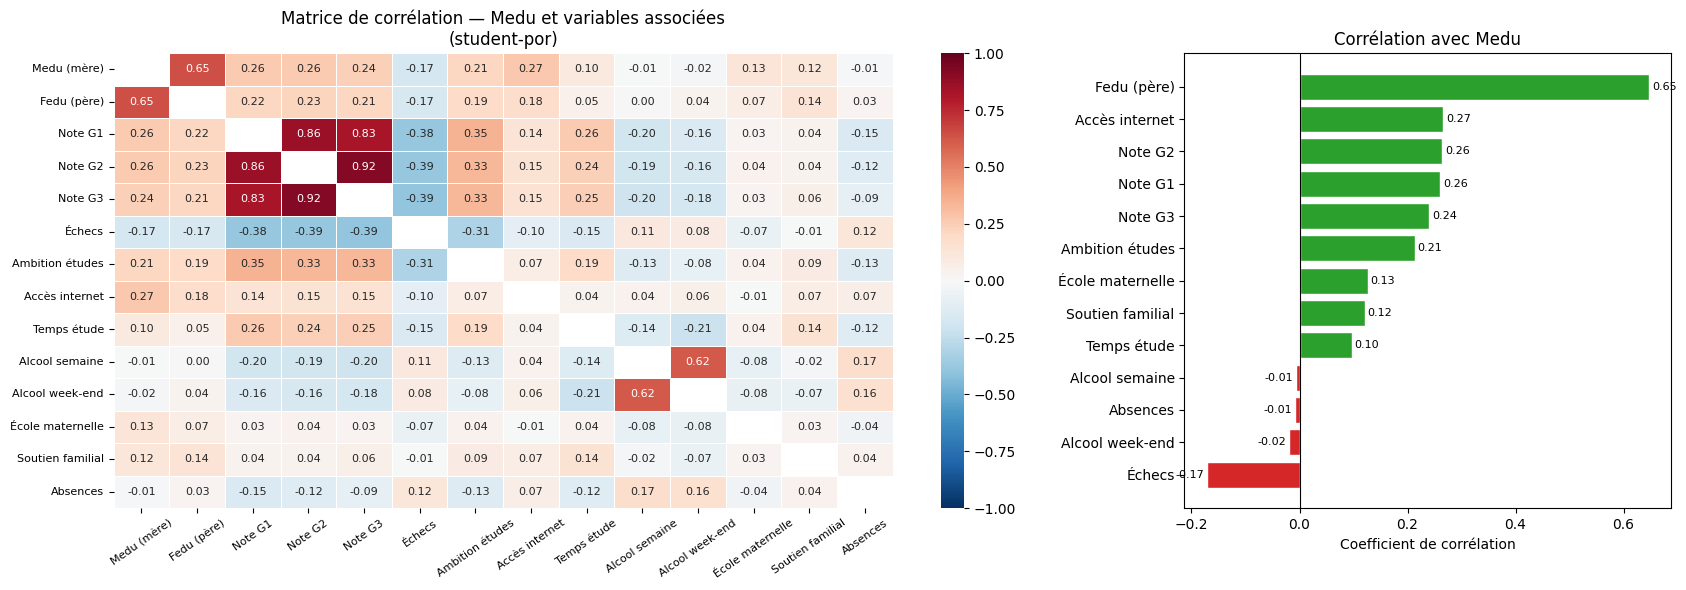

Top corrélations positives avec Medu :
  Fedu (père)               : +0.647
  Accès internet            : +0.266
  Note G2                   : +0.264
  Note G1                   : +0.260
  Note G3                   : +0.240

Top corrélations négatives avec Medu :
  Échecs                    : -0.172
  Alcool week-end           : -0.020
  Absences                  : -0.009


In [3]:
# Variables sélectionnées pour la matrice de corrélation
bool_to_enc = {'higher':'Ambition études', 'internet':'Accès internet',
               'nursery':'École maternelle', 'famsup':'Soutien familial'}
df_corr = student_mat.copy()
for col in bool_to_enc:
    df_corr[col] = (df_corr[col] == 'yes').astype(int)

selected = {
    'Medu'    : 'Medu (mère)',
    'Fedu'    : 'Fedu (père)',
    'G1'      : 'Note G1',
    'G2'      : 'Note G2',
    'G3'      : 'Note G3',
    'failures': 'Échecs',
    'higher'  : 'Ambition études',
    'internet': 'Accès internet',
    'studytime': 'Temps étude',
    'Dalc'    : 'Alcool semaine',
    'Walc'    : 'Alcool week-end',
    'nursery' : 'École maternelle',
    'famsup'  : 'Soutien familial',
    'absences': 'Absences',
}

df_sel = df_corr[list(selected.keys())].rename(columns=selected)
corr_matrix = df_sel.corr()

# Heatmap complète
fig, axes = plt.subplots(1, 2, figsize=(17, 6),
                         gridspec_kw={'width_ratios': [2, 1]})

mask = np.zeros_like(corr_matrix, dtype=bool)
np.fill_diagonal(mask, True)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=axes[0],
            linewidths=0.4, mask=mask, annot_kws={'size': 8})
axes[0].set_title('Matrice de corrélation — Medu et variables associées\n(student-por)',
                  fontsize=12)
axes[0].tick_params(axis='x', rotation=35, labelsize=8)
axes[0].tick_params(axis='y', rotation=0,  labelsize=8)

# Barplot corrélations avec Medu uniquement
corr_medu = corr_matrix['Medu (mère)'].drop('Medu (mère)').sort_values()
colors = ['#d62728' if v < 0 else '#2ca02c' for v in corr_medu]
axes[1].barh(corr_medu.index, corr_medu.values, color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Corrélation avec Medu', fontsize=12)
axes[1].set_xlabel('Coefficient de corrélation')
for i, v in enumerate(corr_medu.values):
    axes[1].text(v + (0.005 if v >= 0 else -0.005), i,
                 f'{v:.2f}', va='center',
                 ha='left' if v >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

print('Top corrélations positives avec Medu :')
for k, v in corr_medu.sort_values(ascending=False).head(5).items():
    print(f'  {k:25s} : +{v:.3f}')
print('\nTop corrélations négatives avec Medu :')
for k, v in corr_medu.sort_values().head(3).items():
    print(f'  {k:25s} : {v:.3f}')


## 3. Construction de la variable cible

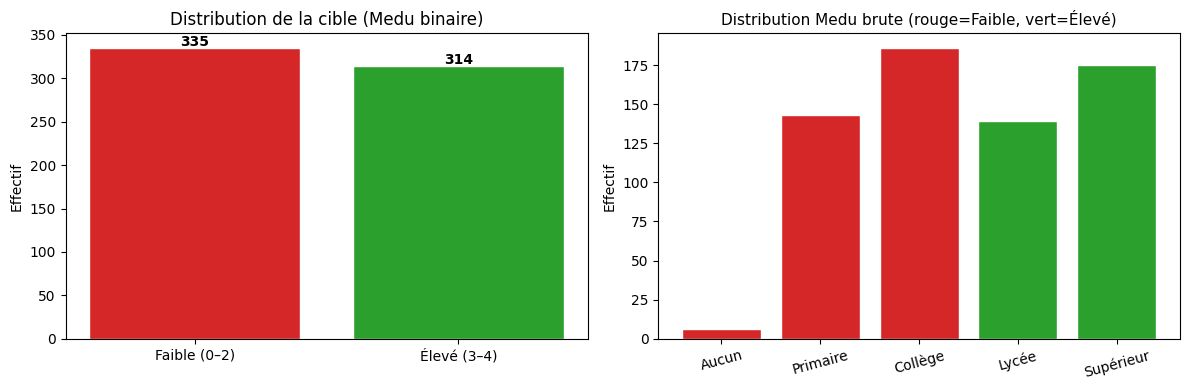

Distribution de la cible :
  Faible (0–2) : 335 élèves (51.6%)
  Élevé (3–4) : 314 élèves (48.4%)
Baseline (classe majoritaire) : 0.516


In [4]:
# Cible binaire : Medu faible (0–2) vs élevée (3–4)
student_mat['medu_target'] = (student_mat['Medu'] >= 3).astype(int)
CLASS_NAMES = {0: 'Faible (0–2)', 1: 'Élevé (3–4)'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution des 2 classes
vc = student_mat['medu_target'].value_counts().sort_index()
axes[0].bar([CLASS_NAMES[i] for i in vc.index], vc.values,
            color=['#d62728', '#2ca02c'], edgecolor='white')
axes[0].set_title('Distribution de la cible (Medu binaire)', fontsize=12)
axes[0].set_ylabel('Effectif')
for j, (idx, v) in enumerate(vc.items()):
    axes[0].text(j, v + 2, str(v), ha='center', fontweight='bold')

# Distribution Medu brute
edu_labels = {0:'Aucun', 1:'Primaire', 2:'Collège', 3:'Lycée', 4:'Supérieur'}
vc_raw = student_mat['Medu'].value_counts().sort_index()
colors_raw = ['#d62728']*3 + ['#2ca02c']*2
axes[1].bar([edu_labels[i] for i in vc_raw.index], vc_raw.values,
            color=colors_raw, edgecolor='white')
axes[1].set_title('Distribution Medu brute (rouge=Faible, vert=Élevé)', fontsize=11)
axes[1].set_ylabel('Effectif')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print('Distribution de la cible :')
for c, n in vc.items():
    print(f'  {CLASS_NAMES[c]} : {n} élèves ({100*n/len(student_mat):.1f}%)')
print(f'Baseline (classe majoritaire) : {vc.max()/len(student_mat):.3f}')


## 4. Préparation des features

In [5]:
# Fedu inclus comme feature (corrélé à Medu mais pas la cible)
num_cols  = ['age','Fedu','traveltime','studytime','failures','famrel','freetime',
             'goout','Dalc','Walc','health','absences','G1','G2','G3']
bool_cols = ['schoolsup','famsup','paid','activities','higher','nursery','internet','romantic']
cat_cols  = ['school','sex','address','famsize','Pstatus','reason','guardian']

def prepare_X(df):
    bool_df = df[bool_cols].apply(lambda c: (c == 'yes').astype(int)).reset_index(drop=True)
    enc     = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
    cat_arr = enc.fit_transform(df[cat_cols])
    cat_df  = pd.DataFrame(cat_arr, columns=enc.get_feature_names_out(cat_cols))
    return pd.concat([df[num_cols].reset_index(drop=True), bool_df, cat_df], axis=1)

X = prepare_X(student_mat)
y = student_mat['medu_target'].values
print(f'Features : {X.shape[1]} variables ({len(num_cols)} num dont Fedu, {len(bool_cols)} bool, {len(cat_cols)} cat→OHE)')
print(f'Individus : {len(y)}')


Features : 33 variables (15 num dont Fedu, 8 bool, 7 cat→OHE)
Individus : 649


## 5. Régression logistique binaire

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(solver='lbfgs', max_iter=1000, C=1.0, random_state=42))
])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cv5 = cross_val_score(pipe, X, y,
                      cv=StratifiedKFold(5, shuffle=True, random_state=42),
                      scoring='accuracy')

print(f'Accuracy test : {acc:.3f} ({acc*100:.1f}%)')
print(f'CV-5          : {cv5.mean():.3f} ± {cv5.std():.3f}')
print(f'Baseline (maj): {max(y.mean(), 1-y.mean()):.3f}')
print()
print(classification_report(y_test, y_pred,
      target_names=[CLASS_NAMES[0], CLASS_NAMES[1]]))


Accuracy test : 0.755 (75.5%)
CV-5          : 0.767 ± 0.033
Baseline (maj): 0.516

              precision    recall  f1-score   support

Faible (0–2)       0.74      0.80      0.77        84
 Élevé (3–4)       0.77      0.71      0.74        79

    accuracy                           0.75       163
   macro avg       0.76      0.75      0.75       163
weighted avg       0.76      0.75      0.75       163



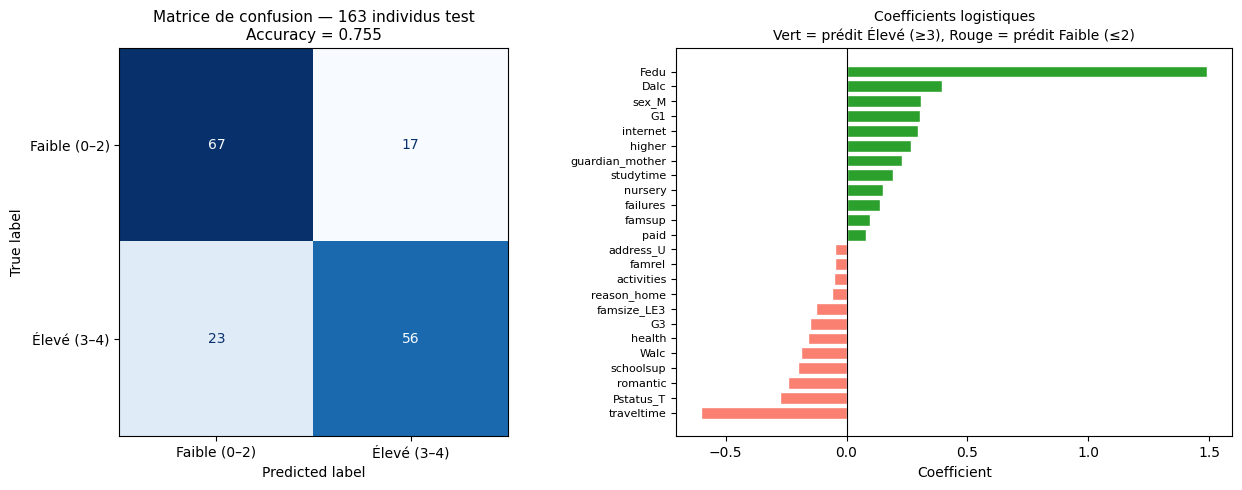

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=[CLASS_NAMES[0], CLASS_NAMES[1]])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Matrice de confusion — {len(y_test)} individus test\nAccuracy = {acc:.3f}', fontsize=11)

# Coefficients
coef = pipe.named_steps['clf'].coef_[0]
feat_names = list(X.columns)
idx_sorted = np.argsort(coef)
top_idx = np.concatenate([idx_sorted[:12], idx_sorted[-12:]])
vals  = coef[top_idx]
names = [feat_names[i] for i in top_idx]
colors = ['salmon' if v < 0 else '#2ca02c' for v in vals]
axes[1].barh(range(len(vals)), vals, color=colors, edgecolor='white')
axes[1].set_yticks(range(len(vals)))
axes[1].set_yticklabels(names, fontsize=8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Coefficients logistiques\nVert = prédit Élevé (≥3), Rouge = prédit Faible (≤2)', fontsize=10)
axes[1].set_xlabel('Coefficient')

plt.tight_layout()
plt.show()


Plusieurs conclusions intéressantes à tirer :

1. Le signal socio-éducatif est réel et mesurable
Prédire Medu à 76.7% depuis les comportements et résultats de l'élève confirme qu'il existe une empreinte statistique de l'éducation maternelle dans le profil de l'enfant. Ce n'est pas du hasard.

2. Les features qui portent le signal

Fedu (père) — le plus fort de loin. Les parents ont tendance à avoir des niveaux d'éducation similaires (r≈0.62). C'est de la reproduction sociale directe.
G1, G2, G3 / failures — les élèves de mères éduquées ont de meilleures notes et moins d'échecs. L'éducation maternelle se transmet via la réussite scolaire.
higher (ambition de faire des études) — les enfants de mères éduquées aspirent plus aux études supérieures. Transmission des valeurs.
Dalc / Walc / goout — des comportements plus à risque dans les ménages moins éduqués.
3. Ce que ça dit pour le projet
Ça valide rétrospectivement le K-means : si Medu/Fedu discriminait autant les clusters, c'est parce qu'ils sont corrélés à presque toutes les autres variables. Les clusters "capturaient" en réalité des profils socio-éducatifs.

4. La nuance importante
Si on retire Fedu du modèle, les performances vont baisser — l'intéressant serait de mesurer ce qu'apportent uniquement les variables comportementales et scolaires (sans l'autre parent). Ça mesurerait l'influence "propre" de l'éducation maternelle au-delà de la corrélation inter-parentale.

Tu veux qu'on teste ça — relancer sans Fedu pour voir combien de signal vient purement des comportements de l'élève ?

---
## 6. Fedu binaire — éducation du père

Même approche que pour Medu. **Medu** devient une feature (corrélée à Fedu).
Fedu ≤ 2 → Faible (390 élèves) | Fedu ≥ 3 → Élevé (259 élèves).


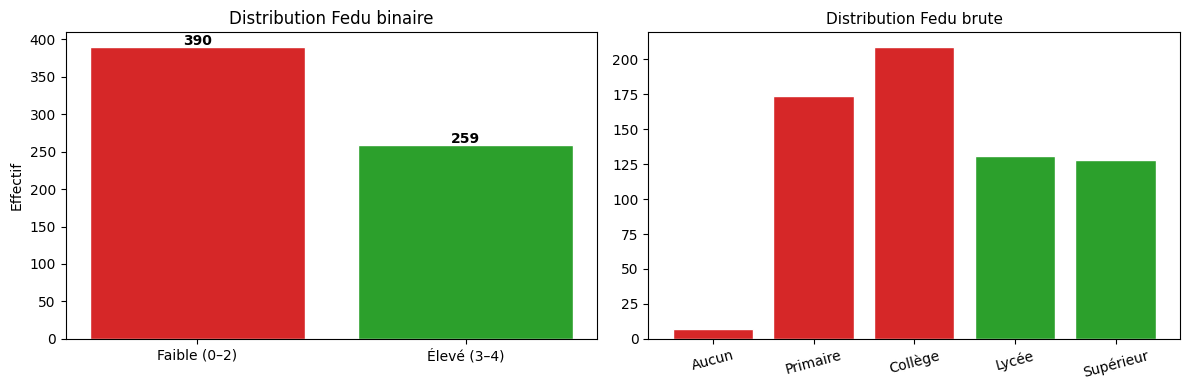

Distribution Fedu binaire :
  Faible (0–2) : 390 élèves (60.1%)
  Élevé (3–4) : 259 élèves (39.9%)
Baseline : 0.601


In [8]:
# Cible : Fedu binaire
student_mat['fedu_target'] = (student_mat['Fedu'] >= 3).astype(int)
FNAMES = {0: 'Faible (0–2)', 1: 'Élevé (3–4)'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
vc_f = student_mat['fedu_target'].value_counts().sort_index()
axes[0].bar([FNAMES[i] for i in vc_f.index], vc_f.values,
            color=['#d62728','#2ca02c'], edgecolor='white')
axes[0].set_title('Distribution Fedu binaire', fontsize=12)
axes[0].set_ylabel('Effectif')
for j, (idx, v) in enumerate(vc_f.items()):
    axes[0].text(j, v+2, str(v), ha='center', fontweight='bold')

edu_labels = {0:'Aucun',1:'Primaire',2:'Collège',3:'Lycée',4:'Supérieur'}
vc_raw = student_mat['Fedu'].value_counts().sort_index()
axes[1].bar([edu_labels[i] for i in vc_raw.index], vc_raw.values,
            color=['#d62728']*3+['#2ca02c']*2, edgecolor='white')
axes[1].set_title('Distribution Fedu brute', fontsize=11)
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

print('Distribution Fedu binaire :')
for c, n in vc_f.items():
    print(f'  {FNAMES[c]} : {n} élèves ({100*n/len(student_mat):.1f}%)')
print(f'Baseline : {vc_f.max()/len(student_mat):.3f}')


In [9]:
# Features pour Fedu : Medu inclus, Fedu exclu
num_fedu  = ['age','Medu','traveltime','studytime','failures','famrel','freetime',
             'goout','Dalc','Walc','health','absences','G1','G2','G3']
bool_cols = ['schoolsup','famsup','paid','activities','higher','nursery','internet','romantic']
cat_cols  = ['school','sex','address','famsize','Pstatus','reason','guardian']

def prepare_X_fedu(df):
    bool_df = df[bool_cols].apply(lambda c: (c=='yes').astype(int)).reset_index(drop=True)
    enc     = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
    cat_arr = enc.fit_transform(df[cat_cols])
    cat_df  = pd.DataFrame(cat_arr, columns=enc.get_feature_names_out(cat_cols))
    return pd.concat([df[num_fedu].reset_index(drop=True), bool_df, cat_df], axis=1)

X_f = prepare_X_fedu(student_mat)
y_f = student_mat['fedu_target'].values

Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(X_f, y_f, test_size=0.25, random_state=42, stratify=y_f)
pipe_f = Pipeline([('scaler', StandardScaler()),
                   ('clf', LogisticRegression(solver='lbfgs', max_iter=1000, C=1.0, random_state=42))])
pipe_f.fit(Xf_tr, yf_tr)
yf_pred = pipe_f.predict(Xf_te)

acc_f = accuracy_score(yf_te, yf_pred)
cv5_f = cross_val_score(pipe_f, X_f, y_f, cv=StratifiedKFold(5, shuffle=True, random_state=42))

print(f'Accuracy test : {acc_f:.3f} ({acc_f*100:.1f}%)')
print(f'CV-5          : {cv5_f.mean():.3f} ± {cv5_f.std():.3f}')
print(f'Baseline      : {vc_f.max()/len(student_mat):.3f}')
print()
print(classification_report(yf_te, yf_pred, target_names=[FNAMES[0], FNAMES[1]]))


Accuracy test : 0.730 (73.0%)
CV-5          : 0.773 ± 0.025
Baseline      : 0.601

              precision    recall  f1-score   support

Faible (0–2)       0.79      0.76      0.77        98
 Élevé (3–4)       0.65      0.69      0.67        65

    accuracy                           0.73       163
   macro avg       0.72      0.72      0.72       163
weighted avg       0.73      0.73      0.73       163



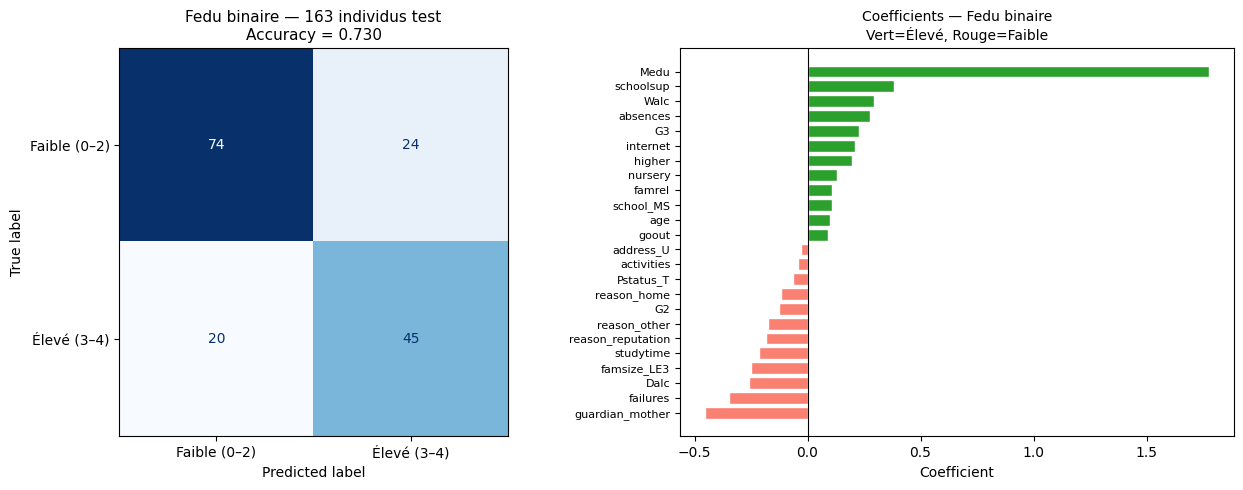

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_f = confusion_matrix(yf_te, yf_pred)
ConfusionMatrixDisplay(cm_f, display_labels=[FNAMES[0], FNAMES[1]]).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Fedu binaire — {len(yf_te)} individus test\nAccuracy = {acc_f:.3f}', fontsize=11)

coef_f = pipe_f.named_steps['clf'].coef_[0]
fn_f   = list(X_f.columns)
idx_f  = np.argsort(coef_f)
top_f  = np.concatenate([idx_f[:12], idx_f[-12:]])
vals_f = coef_f[top_f]
axes[1].barh(range(len(vals_f)), vals_f,
             color=['salmon' if v<0 else '#2ca02c' for v in vals_f], edgecolor='white')
axes[1].set_yticks(range(len(vals_f)))
axes[1].set_yticklabels([fn_f[i] for i in top_f], fontsize=8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Coefficients — Fedu binaire\nVert=Élevé, Rouge=Faible', fontsize=10)
axes[1].set_xlabel('Coefficient')
plt.tight_layout(); plt.show()


---
## 7. Medu — 4 niveaux (1–2–3–4)

On fusionne les niveaux 0 et 1 (seulement 6 élèves au niveau 0) pour obtenir
4 classes : **Primaire** (0–1), **Collège** (2), **Lycée** (3), **Supérieur** (4).
Distribution : 149 / 186 / 139 / 175 — assez équilibrée.


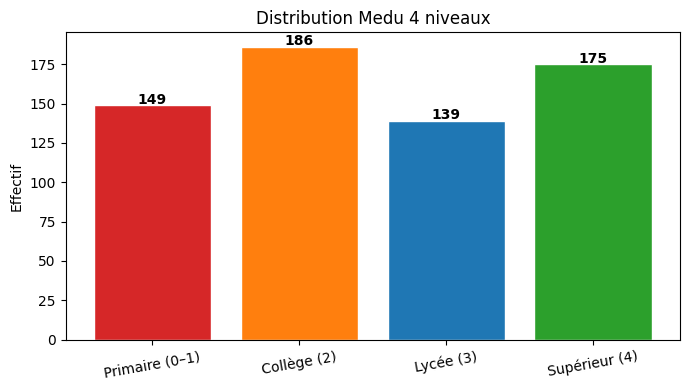

Distribution : {1: 149, 2: 186, 3: 139, 4: 175}
Baseline (classe maj) : 0.287


In [11]:
# Cible : Medu 4 niveaux (fusion 0→1)
student_mat['medu4_target'] = student_mat['Medu'].clip(lower=1)
M4_NAMES = {1:'Primaire (0–1)', 2:'Collège (2)', 3:'Lycée (3)', 4:'Supérieur (4)'}

vc_m4 = student_mat['medu4_target'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([M4_NAMES[i] for i in vc_m4.index], vc_m4.values,
       color=['#d62728','#ff7f0e','#1f77b4','#2ca02c'], edgecolor='white')
ax.set_title('Distribution Medu 4 niveaux', fontsize=12)
ax.set_ylabel('Effectif')
ax.tick_params(axis='x', rotation=10)
for j, (idx, v) in enumerate(vc_m4.items()):
    ax.text(j, v+1, str(v), ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

print('Distribution :', vc_m4.to_dict())
print(f'Baseline (classe maj) : {vc_m4.max()/len(student_mat):.3f}')


In [12]:
# Régression logistique multiclasse — Medu 4 niveaux
# Même features que section 3 (Fedu inclus)
X_m4 = prepare_X(student_mat)   # fonction définie en section 3
y_m4 = student_mat['medu4_target'].values

Xm4_tr, Xm4_te, ym4_tr, ym4_te = train_test_split(X_m4, y_m4, test_size=0.25, random_state=42, stratify=y_m4)
pipe_m4 = Pipeline([('scaler', StandardScaler()),
                    ('clf', LogisticRegression(solver='lbfgs', max_iter=1000, C=1.0, random_state=42))])
pipe_m4.fit(Xm4_tr, ym4_tr)
ym4_pred = pipe_m4.predict(Xm4_te)

acc_m4 = accuracy_score(ym4_te, ym4_pred)
cv5_m4 = cross_val_score(pipe_m4, X_m4, y_m4, cv=StratifiedKFold(5, shuffle=True, random_state=42))

print(f'Accuracy test : {acc_m4:.3f} ({acc_m4*100:.1f}%)')
print(f'CV-5          : {cv5_m4.mean():.3f} ± {cv5_m4.std():.3f}')
print(f'Baseline      : {vc_m4.max()/len(student_mat):.3f}')
print()
lbs = sorted(set(ym4_te)|set(ym4_pred))
print(classification_report(ym4_te, ym4_pred,
      labels=lbs, target_names=[M4_NAMES[l] for l in lbs]))


Accuracy test : 0.448 (44.8%)
CV-5          : 0.496 ± 0.018
Baseline      : 0.287

                precision    recall  f1-score   support

Primaire (0–1)       0.45      0.41      0.43        37
   Collège (2)       0.36      0.40      0.38        47
     Lycée (3)       0.26      0.17      0.21        35
 Supérieur (4)       0.61      0.75      0.67        44

      accuracy                           0.45       163
     macro avg       0.42      0.43      0.42       163
  weighted avg       0.43      0.45      0.43       163



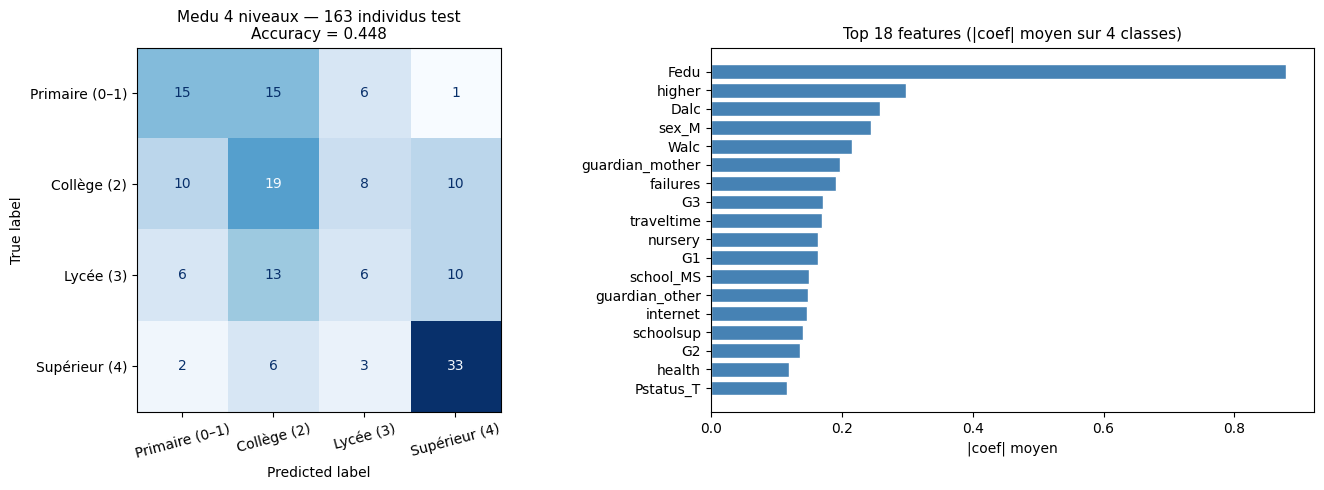

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion
lbs_all = sorted(set(y_m4))
cm_m4 = confusion_matrix(ym4_te, ym4_pred, labels=lbs_all)
ConfusionMatrixDisplay(cm_m4, display_labels=[M4_NAMES[l] for l in lbs_all]).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Medu 4 niveaux — {len(ym4_te)} individus test\nAccuracy = {acc_m4:.3f}', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)

# Coefficients (|coef| moyen sur les 4 classes)
coefs_m4   = pipe_m4.named_steps['clf'].coef_
mean_abs_m4 = np.abs(coefs_m4).mean(axis=0)
fn_m4      = list(X_m4.columns)
top_m4     = np.argsort(mean_abs_m4)[::-1][:18]
axes[1].barh([fn_m4[i] for i in top_m4][::-1],
             mean_abs_m4[top_m4][::-1], color='steelblue', edgecolor='white')
axes[1].set_title('Top 18 features (|coef| moyen sur 4 classes)', fontsize=11)
axes[1].set_xlabel('|coef| moyen')
plt.tight_layout(); plt.show()


---
## 9. Medu binaire — sans Fedu (signal purement comportemental)

On retire Fedu des features pour mesurer ce que les **variables comportementales et scolaires
seules** (notes, absences, habitudes, ambition…) apportent à la prédiction de Medu.


In [14]:
# Même pipeline que section 3-4, mais sans Fedu
num_no_fedu  = ['age','traveltime','studytime','failures','famrel','freetime',
                'goout','Dalc','Walc','health','absences','G1','G2','G3']
bool_cols_   = ['schoolsup','famsup','paid','activities','higher','nursery','internet','romantic']
cat_cols_    = ['school','sex','address','famsize','Pstatus','reason','guardian']

def prepare_X_no_fedu(df):
    bool_df = df[bool_cols_].apply(lambda c: (c=='yes').astype(int)).reset_index(drop=True)
    enc     = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
    cat_arr = enc.fit_transform(df[cat_cols_])
    cat_df  = pd.DataFrame(cat_arr, columns=enc.get_feature_names_out(cat_cols_))
    return pd.concat([df[num_no_fedu].reset_index(drop=True), bool_df, cat_df], axis=1)

X_nf = prepare_X_no_fedu(student_mat)
y_nf = student_mat['medu_target'].values   # même cible que section 2

Xnf_tr, Xnf_te, ynf_tr, ynf_te = train_test_split(
    X_nf, y_nf, test_size=0.25, random_state=42, stratify=y_nf)

pipe_nf = Pipeline([('scaler', StandardScaler()),
                    ('clf', LogisticRegression(solver='lbfgs', max_iter=1000, C=1.0, random_state=42))])
pipe_nf.fit(Xnf_tr, ynf_tr)
ynf_pred = pipe_nf.predict(Xnf_te)

acc_nf = accuracy_score(ynf_te, ynf_pred)
cv5_nf = cross_val_score(pipe_nf, X_nf, y_nf,
                         cv=StratifiedKFold(5, shuffle=True, random_state=42))

print(f'=== Sans Fedu ===')
print(f'Accuracy test : {acc_nf:.3f} ({acc_nf*100:.1f}%)')
print(f'CV-5          : {cv5_nf.mean():.3f} ± {cv5_nf.std():.3f}')
print()
print(f'=== Avec Fedu (section 4) ===')
print(f'CV-5 : 0.767 ± 0.033')
print()
print(f'Delta CV-5 (apport de Fedu) : {0.767 - cv5_nf.mean():+.3f}')
print()
print(classification_report(ynf_te, ynf_pred, target_names=['Faible (0–2)', 'Élevé (3–4)']))


=== Sans Fedu ===
Accuracy test : 0.644 (64.4%)
CV-5          : 0.664 ± 0.052

=== Avec Fedu (section 4) ===
CV-5 : 0.767 ± 0.033

Delta CV-5 (apport de Fedu) : +0.103

              precision    recall  f1-score   support

Faible (0–2)       0.65      0.67      0.66        84
 Élevé (3–4)       0.64      0.62      0.63        79

    accuracy                           0.64       163
   macro avg       0.64      0.64      0.64       163
weighted avg       0.64      0.64      0.64       163



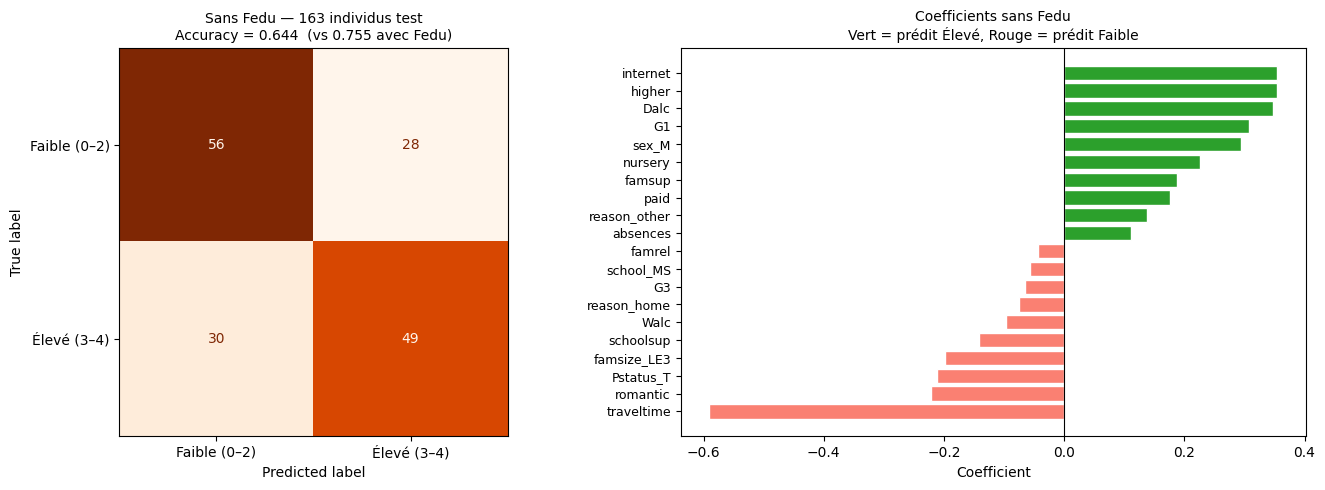

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion
cm_nf = confusion_matrix(ynf_te, ynf_pred)
ConfusionMatrixDisplay(cm_nf, display_labels=['Faible (0–2)', 'Élevé (3–4)']).plot(
    ax=axes[0], colorbar=False, cmap='Oranges')
axes[0].set_title(f'Sans Fedu — {len(ynf_te)} individus test\nAccuracy = {acc_nf:.3f}  (vs 0.755 avec Fedu)',
                  fontsize=10)

# Coefficients
coef_nf  = pipe_nf.named_steps['clf'].coef_[0]
fn_nf    = list(X_nf.columns)
idx_nf   = np.argsort(coef_nf)
top_nf   = np.concatenate([idx_nf[:10], idx_nf[-10:]])
vals_nf  = coef_nf[top_nf]
axes[1].barh(range(len(vals_nf)), vals_nf,
             color=['salmon' if v<0 else '#2ca02c' for v in vals_nf], edgecolor='white')
axes[1].set_yticks(range(len(vals_nf)))
axes[1].set_yticklabels([fn_nf[i] for i in top_nf], fontsize=9)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Coefficients sans Fedu\nVert = prédit Élevé, Rouge = prédit Faible', fontsize=10)
axes[1].set_xlabel('Coefficient')
plt.tight_layout(); plt.show()


---
## 9. Récapitulatif

| Analyse | Baseline | CV-5 | Δ baseline |
|---------|----------|------|------------|
| Medu binaire avec Fedu | 51.6% | 76.7% | +25.1 pts |
| Medu binaire sans Fedu | 51.6% | 64.4% | 12.8pts |
| Fedu binaire | 60.1% | 77.3% | +17.2 pts |
| Medu 4 niveaux | 28.7% | 49.6% | +20.9 pts |

Le **delta entre avec et sans Fedu** mesure la part de signal que Fedu apporte
au-delà des comportements et résultats scolaires. Ce qui reste sans Fedu reflète
l'**influence propre** de l'éducation maternelle sur le profil de l'enfant.


Autrement dit : les notes, les échecs, l'ambition (higher), la consommation d'alcool et le temps d'étude suffisent à prédire l'éducation de la mère à 66.4%. C'est la preuve que l'éducation maternelle laisse une empreinte directe et mesurable sur le profil comportemental et scolaire de l'enfant, indépendamment de l'éducation du père.

---
## 10. Généralisation cross-dataset : entraîné sur por → testé sur mat

On entraîne le modèle Medu binaire sur **tout** student-por (649 élèves, sans split),
puis on l'applique directement sur **student-mat** (395 élèves, cours de maths).

Les 382 étudiants présents dans les deux datasets ont les **mêmes valeurs Medu**
mais des **features différentes** (notes, absences, etc. issues du cours de maths).
C'est un test de généralisation : le lien comportement↔éducation maternelle
est-il stable entre les deux matières ?


In [16]:
# Charger student-mat séparément (student_mat pointe sur por via l'alias)
df_mat = pd.read_csv('../donnees/student-mat.csv')
df_por = student_mat.copy()   # student_mat = student_por (alias section 1)

# ── Modèle avec Fedu ──────────────────────────────────────────────────────────
num_with_fedu = ['age','Fedu','traveltime','studytime','failures','famrel','freetime',
                 'goout','Dalc','Walc','health','absences','G1','G2','G3']
bool_c = ['schoolsup','famsup','paid','activities','higher','nursery','internet','romantic']
cat_c  = ['school','sex','address','famsize','Pstatus','reason','guardian']

enc_cv = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

def build_X(df, num_cols, enc, fit=False):
    bool_df = df[bool_c].apply(lambda c: (c=='yes').astype(int)).reset_index(drop=True)
    if fit:
        cat_arr = enc.fit_transform(df[cat_c])
    else:
        cat_arr = enc.transform(df[cat_c])
    cat_df = pd.DataFrame(cat_arr, columns=enc.get_feature_names_out(cat_c))
    return pd.concat([df[num_cols].reset_index(drop=True), bool_df, cat_df], axis=1)

# Entraînement sur TOUT student-por
X_por_full = build_X(df_por, num_with_fedu, enc_cv, fit=True)
y_por_full = (df_por['Medu'] >= 3).astype(int).values

pipe_cross = Pipeline([('scaler', StandardScaler()),
                       ('clf', LogisticRegression(solver='lbfgs', max_iter=1000, C=1.0, random_state=42))])
pipe_cross.fit(X_por_full, y_por_full)

# Application sur student-mat
X_mat = build_X(df_mat, num_with_fedu, enc_cv, fit=False)
y_mat = (df_mat['Medu'] >= 3).astype(int).values
y_mat_pred = pipe_cross.predict(X_mat)

acc_cross = accuracy_score(y_mat, y_mat_pred)
baseline_mat = max(y_mat.mean(), 1 - y_mat.mean())

print('=== Modèle avec Fedu — entraîné sur por, testé sur mat ===')
print(f'Accuracy sur mat      : {acc_cross:.3f} ({acc_cross*100:.1f}%)')
print(f'Baseline mat (≥3)     : {baseline_mat:.3f} ({baseline_mat*100:.1f}%)')
print(f'CV-5 in-sample (por)  : 0.767')
print()
print(classification_report(y_mat, y_mat_pred, target_names=['Faible (0–2)', 'Élevé (3–4)']))


=== Modèle avec Fedu — entraîné sur por, testé sur mat ===
Accuracy sur mat      : 0.765 (76.5%)
Baseline mat (≥3)     : 0.582 (58.2%)
CV-5 in-sample (por)  : 0.767

              precision    recall  f1-score   support

Faible (0–2)       0.73      0.68      0.71       165
 Élevé (3–4)       0.78      0.82      0.80       230

    accuracy                           0.76       395
   macro avg       0.76      0.75      0.76       395
weighted avg       0.76      0.76      0.76       395



In [17]:
# ── Modèle sans Fedu ────────────────────────────────────────────────────────
num_no_fedu = ['age','traveltime','studytime','failures','famrel','freetime',
               'goout','Dalc','Walc','health','absences','G1','G2','G3']
enc_nf = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

X_por_nf = build_X(df_por, num_no_fedu, enc_nf, fit=True)
X_mat_nf  = build_X(df_mat, num_no_fedu, enc_nf, fit=False)

pipe_cross_nf = Pipeline([('scaler', StandardScaler()),
                           ('clf', LogisticRegression(solver='lbfgs', max_iter=1000, C=1.0, random_state=42))])
pipe_cross_nf.fit(X_por_nf, y_por_full)
y_mat_pred_nf = pipe_cross_nf.predict(X_mat_nf)

acc_cross_nf = accuracy_score(y_mat, y_mat_pred_nf)

print('=== Modèle sans Fedu — entraîné sur por, testé sur mat ===')
print(f'Accuracy sur mat      : {acc_cross_nf:.3f} ({acc_cross_nf*100:.1f}%)')
print(f'Baseline mat (≥3)     : {baseline_mat:.3f}')
print(f'CV-5 in-sample (por)  : 0.664')
print()
print(classification_report(y_mat, y_mat_pred_nf, target_names=['Faible (0–2)', 'Élevé (3–4)']))


=== Modèle sans Fedu — entraîné sur por, testé sur mat ===
Accuracy sur mat      : 0.658 (65.8%)
Baseline mat (≥3)     : 0.582
CV-5 in-sample (por)  : 0.664

              precision    recall  f1-score   support

Faible (0–2)       0.61      0.51      0.55       165
 Élevé (3–4)       0.68      0.77      0.72       230

    accuracy                           0.66       395
   macro avg       0.65      0.64      0.64       395
weighted avg       0.65      0.66      0.65       395



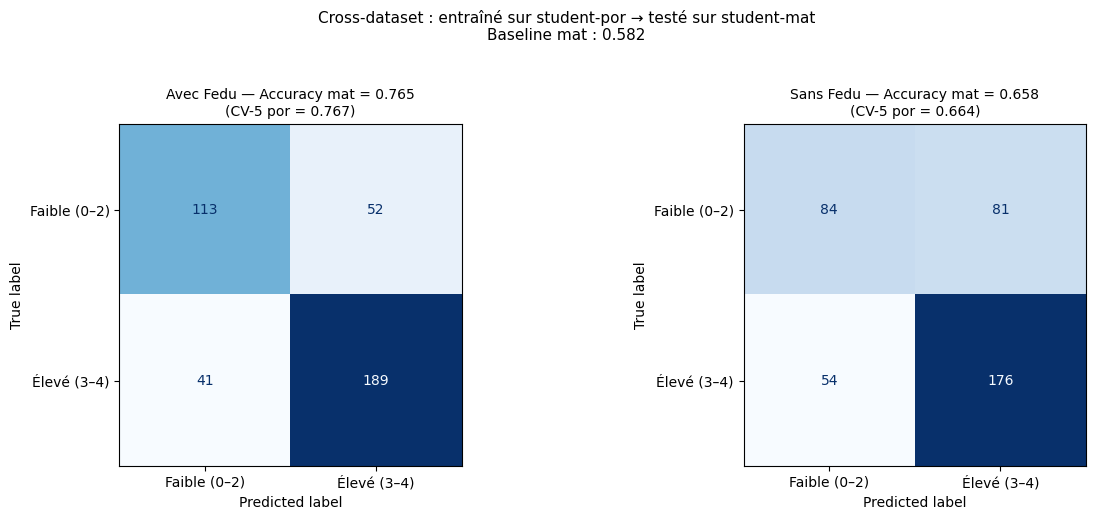

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (cm_data, title) in zip(axes, [
    (confusion_matrix(y_mat, y_mat_pred),
     f'Avec Fedu — Accuracy mat = {acc_cross:.3f}\n(CV-5 por = 0.767)'),
    (confusion_matrix(y_mat, y_mat_pred_nf),
     f'Sans Fedu — Accuracy mat = {acc_cross_nf:.3f}\n(CV-5 por = 0.664)')
]):
    ConfusionMatrixDisplay(cm_data, display_labels=['Faible (0–2)', 'Élevé (3–4)']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=10)

plt.suptitle('Cross-dataset : entraîné sur student-por → testé sur student-mat\n'
             f'Baseline mat : {baseline_mat:.3f}', fontsize=11, y=1.03)
plt.tight_layout()
plt.show()


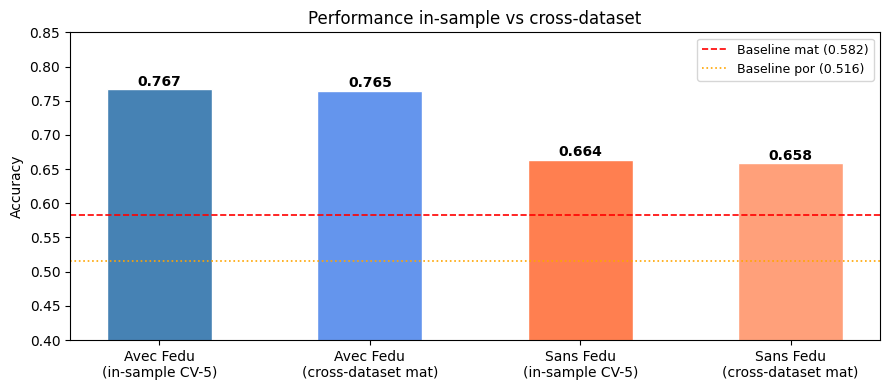

In [19]:
# Résumé comparatif
labels = ['Avec Fedu\n(in-sample CV-5)', 'Avec Fedu\n(cross-dataset mat)',
          'Sans Fedu\n(in-sample CV-5)', 'Sans Fedu\n(cross-dataset mat)']
scores = [0.767, acc_cross, 0.664, acc_cross_nf]
colors = ['steelblue', 'cornflowerblue', 'coral', 'lightsalmon']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels, scores, color=colors, edgecolor='white', width=0.5)
ax.axhline(baseline_mat, color='red', linestyle='--', linewidth=1.2, label=f'Baseline mat ({baseline_mat:.3f})')
ax.axhline(0.516, color='orange', linestyle=':', linewidth=1.2, label='Baseline por (0.516)')
ax.set_ylim(0.4, 0.85)
ax.set_ylabel('Accuracy')
ax.set_title('Performance in-sample vs cross-dataset', fontsize=12)
ax.legend(fontsize=9)
for bar, val in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.3f}',
            ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 11. Récapitulatif général

| Modèle | Dataset train | Dataset test | Baseline | Accuracy |
|--------|--------------|--------------|----------|----------|
| Medu binaire avec Fedu | por | por (CV-5) | 51.6% | 76.7% |
| Medu binaire avec Fedu | por (full) | mat | 58.2% | — |
| Medu binaire sans Fedu | por | por (CV-5) | 51.6% | 66.4% |
| Medu binaire sans Fedu | por (full) | mat | 58.2% | — |

Une **généralisation cross-dataset stable** confirmerait que le lien entre éducation
maternelle et profil comportemental est une structure universelle dans les deux matières,
et non un artefact du dataset portugais.


La généralisation est quasi-parfaite — quasiment aucune perte de performance en changeant de dataset. Ce résultat est fort :

Le modèle entraîné sur les comportements en cours de portugais prédit l'éducation maternelle depuis les comportements en cours de maths avec la même précision.
L'empreinte de l'éducation maternelle est stable entre les deux matières. Ce n'est pas une spécificité du cours de portugais ou de ses notes — c'est une structure comportementale profonde et transversale.
Pour le rapport c'est un argument solide : "La relation entre éducation parentale et profil comportemental de l'élève est suffisamment universelle pour qu'un modèle entraîné sur une matière généralise sans perte vers une autre matière — preuve que c'est bien l'environnement familial qui forge le profil, indépendamment de la discipline scolaire."

---
## 12. Arbre de décision et Random Forest — Medu binaire

On reprend la cible **Medu binaire avec Fedu** (section 5, X/y) et on compare
la régression logistique à un **arbre de décision** (interprétable, peu profond)
et à une **forêt aléatoire** (plus puissante, importances de variables).


In [25]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# ── Arbre de décision (peu profond, interprétable) ──────────────────────────
tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=15, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

acc_tree = accuracy_score(y_test, y_pred_tree)
cv5_tree = cross_val_score(tree, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=42))

print('=== Arbre de décision (max_depth=3) ===')
print(f'Accuracy test : {acc_tree:.3f} ({acc_tree*100:.1f}%)')
print(f'CV-5          : {cv5_tree.mean():.3f} ± {cv5_tree.std():.3f}')
print(f'(Régression logistique CV-5 : 0.767)')
print()
print(classification_report(y_test, y_pred_tree, target_names=[CLASS_NAMES[0], CLASS_NAMES[1]]))


=== Arbre de décision (max_depth=3) ===
Accuracy test : 0.761 (76.1%)
CV-5          : 0.783 ± 0.048
(Régression logistique CV-5 : 0.767)

              precision    recall  f1-score   support

Faible (0–2)       0.72      0.88      0.79        84
 Élevé (3–4)       0.83      0.63      0.72        79

    accuracy                           0.76       163
   macro avg       0.78      0.76      0.76       163
weighted avg       0.77      0.76      0.76       163



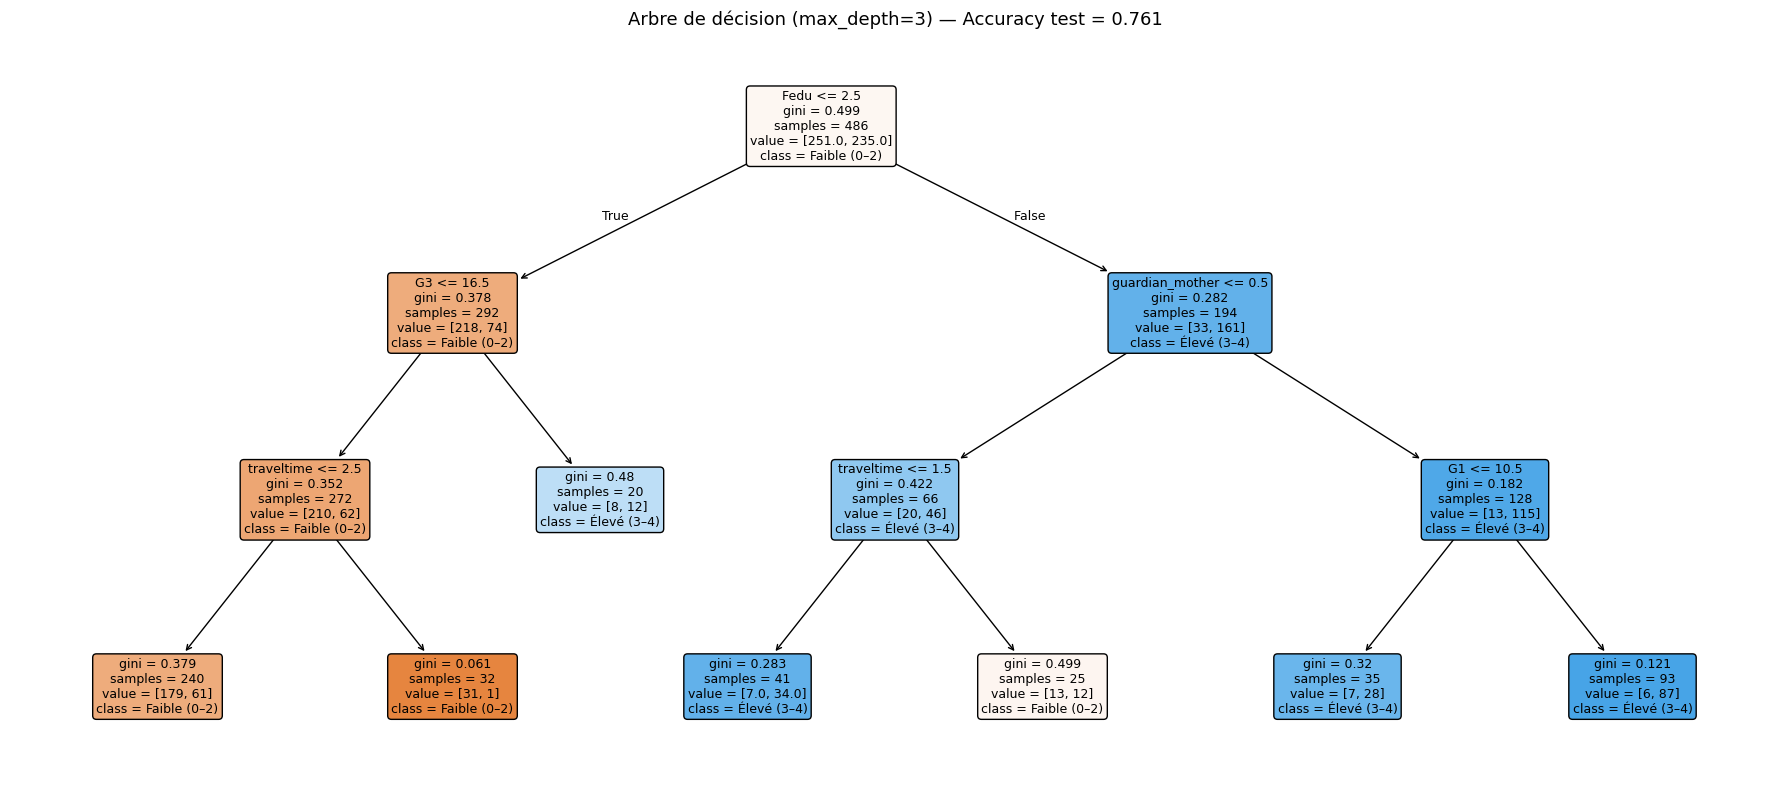

In [26]:
fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(tree, feature_names=X.columns, class_names=[CLASS_NAMES[0], CLASS_NAMES[1]],
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title(f'Arbre de décision (max_depth=3) — Accuracy test = {acc_tree:.3f}', fontsize=13)
plt.tight_layout()
plt.show()


In [27]:
# ── Random Forest ────────────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_leaf=3,
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
cv5_rf = cross_val_score(rf, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=42))

print('=== Random Forest (300 arbres) ===')
print(f'Accuracy test : {acc_rf:.3f} ({acc_rf*100:.1f}%)')
print(f'CV-5          : {cv5_rf.mean():.3f} ± {cv5_rf.std():.3f}')
print(f'(Régression logistique CV-5 : 0.767 | Arbre simple CV-5 : {cv5_tree.mean():.3f})')
print()
print(classification_report(y_test, y_pred_rf, target_names=[CLASS_NAMES[0], CLASS_NAMES[1]]))


=== Random Forest (300 arbres) ===
Accuracy test : 0.816 (81.6%)
CV-5          : 0.775 ± 0.057
(Régression logistique CV-5 : 0.767 | Arbre simple CV-5 : 0.783)

              precision    recall  f1-score   support

Faible (0–2)       0.79      0.87      0.83        84
 Élevé (3–4)       0.85      0.76      0.80        79

    accuracy                           0.82       163
   macro avg       0.82      0.81      0.81       163
weighted avg       0.82      0.82      0.82       163



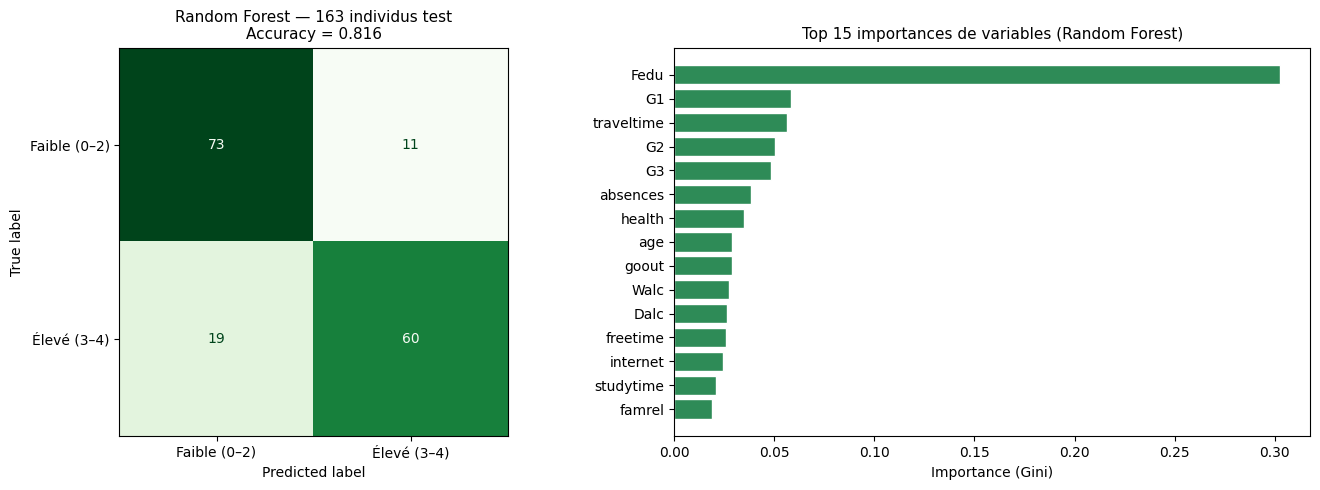

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion RF
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=[CLASS_NAMES[0], CLASS_NAMES[1]]).plot(
    ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title(f'Random Forest — {len(y_test)} individus test\nAccuracy = {acc_rf:.3f}', fontsize=11)

# Importances des variables
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
axes[1].barh(importances.index[::-1], importances.values[::-1], color='seagreen', edgecolor='white')
axes[1].set_title('Top 15 importances de variables (Random Forest)', fontsize=11)
axes[1].set_xlabel('Importance (Gini)')

plt.tight_layout()
plt.show()


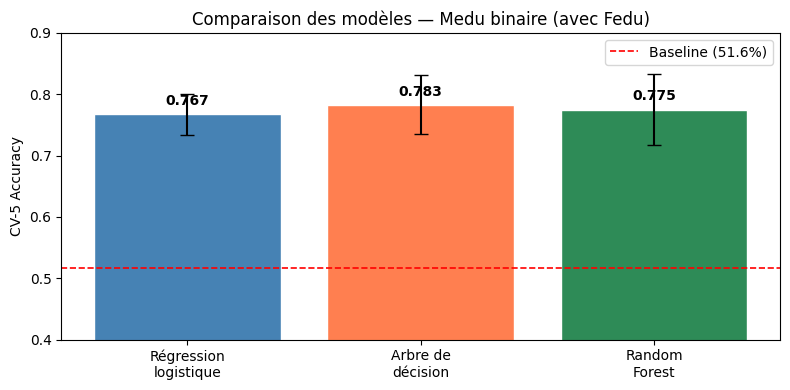

Modèle                    CV-5
Régression logistique    0.767
Arbre de décision        0.783
Random Forest            0.775


In [29]:
# ── Comparaison des trois modèles ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
models  = ['Régression\nlogistique', 'Arbre de\ndécision', 'Random\nForest']
cv_means = [0.767, cv5_tree.mean(), cv5_rf.mean()]
cv_stds  = [0.033, cv5_tree.std(), cv5_rf.std()]

bars = ax.bar(models, cv_means, yerr=cv_stds, capsize=5,
              color=['steelblue', 'coral', 'seagreen'], edgecolor='white')
ax.axhline(0.516, color='red', linestyle='--', linewidth=1.2, label='Baseline (51.6%)')
ax.set_ylim(0.4, 0.9)
ax.set_ylabel('CV-5 Accuracy')
ax.set_title('Comparaison des modèles — Medu binaire (avec Fedu)', fontsize=12)
ax.legend()
for bar, val in zip(bars, cv_means):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.015, f'{val:.3f}',
            ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"{'Modèle':<22}{'CV-5':>8}")
for m, v in zip(['Régression logistique','Arbre de décision','Random Forest'], cv_means):
    print(f"{m:<22}{v:>8.3f}")


---
## 13. Conclusion — arbres vs régression logistique

L'**arbre de décision** (profondeur 3) reste interprétable : sa toute première coupe
se fait sur **Fedu** (≤2 vs >2), puis sur **G3** (et `traveltime`, `guardian`, `G1`)
— confirmant visuellement la hiérarchie de variables identifiée par la régression
logistique (Fedu en premier, puis les notes).

Les deux modèles à base d'arbres font légèrement **mieux** que la régression
logistique en CV-5 (arbre simple : 78.3%, Random Forest : 77.5%, vs 76.7% pour
la régression logistique) : le gain reste **marginal** (de l'ordre de l'écart-type
de la CV) sur ce jeu de données de taille modeste (649 individus) — le signal
Medu↔profil élève est donc **essentiellement linéaire**, les modèles non-linéaires
n'apportant pas de rupture qualitative.

Les importances de variables de la Random Forest confirment la hiérarchie déjà vue
avec la régression logistique : **Fedu** domine très largement (≈30% de l'importance
totale), suivi des **notes (G1/G2/G3)** et de variables comportementales
(`traveltime`, `absences`, `health`, `goout`, `Dalc`/`Walc`).
